# EDA — NABirds Dataset

Notebook này phân tích khám phá dữ liệu (EDA) cho bộ dữ liệu **NABirds** (North American Birds),
làm nền tảng cho 3 dự án deep learning tiếp theo:

1. **Phân loại nhị phân (binary classification)** bằng CNN / ResNet cơ bản.
2. **Phân loại đa lớp (multi-class)** bằng softmax (thường bị gọi nhầm là "multi label" nhưng bản chất
   NABirds là *single-label, multi-class* — mỗi ảnh chỉ có đúng 1 nhãn loài).
3. **Zero-shot classification** (dự đoán các lớp chưa từng thấy khi huấn luyện).

> Notebook chỉ dừng ở bước EDA — không huấn luyện mô hình nào ở đây. Môi trường `deeplearning`
> (conda, có CUDA) sẽ được dùng ở các notebook huấn luyện tiếp theo.

**Cấu trúc notebook:**
1. Giới thiệu cấu trúc thư mục & vai trò từng file
2. Nạp dữ liệu (load toàn bộ file annotation)
3. Ghép dữ liệu thành 1 bảng tổng hợp (master dataframe)
4. Thống kê tổng quan
5. Phân bố lớp (class distribution) & mất cân bằng
6. Phân cấp phân loại (taxonomy hierarchy)
7. Kích thước ảnh & tỉ lệ khung hình
8. Bounding box
9. Bộ phận cơ thể (parts / keypoints)
10. Nhiếp ảnh gia & rủi ro rò rỉ dữ liệu (leakage)
11. Train/test split theo từng lớp
12. Kiểm tra tính toàn vẹn dữ liệu (integrity checks)
13. Trực quan hóa ảnh mẫu
14. Đánh giá khả thi cho 3 dự án (binary / multi-class / zero-shot)
15. Tổng kết & khuyến nghị


In [1]:
import os
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (10, 5)
RNG = np.random.default_rng(42)
random.seed(42)

# Thư mục gốc của dataset (chạy notebook từ thư mục project-dl)
DATA_DIR = Path('nabirds')
IMAGES_DIR = DATA_DIR / 'images'
assert DATA_DIR.exists(), f"Không tìm thấy thư mục dataset: {DATA_DIR.resolve()}"
print('DATA_DIR =', DATA_DIR.resolve())


DATA_DIR = C:\project-dl\nabirds


## 1. Cấu trúc thư mục & vai trò từng file

Dataset gốc: **NABirds v0 (June 2015)** — Cornell Lab of Ornithology / Visipedia.
555 loài/phân loại chim Bắc Mỹ (tính theo giới tính, tuổi, bộ lông — ví dụ *"Baltimore Oriole
(Female/Immature male)"* được tính là 1 "class" riêng).

```
project-dl/
└── nabirds/
    ├── images/                     # 555 thư mục con (1 thư mục / loài), 48,562 ảnh .jpg
    │   └── <class_dir>/*.jpg
    ├── parts/
    │   ├── parts.txt                # tên 11 bộ phận cơ thể (mỏ, đầu, mắt, cánh, đuôi...)
    │   └── part_locs.txt            # toạ độ (x, y) + visibility của từng bộ phận, theo từng ảnh
    ├── images.txt                   # <image_id> <đường_dẫn_ảnh>            — danh sách toàn bộ ảnh
    ├── image_class_labels.txt       # <image_id> <class_id>                — nhãn loài (ground truth)
    ├── classes.txt                  # <class_id> <tên_loài/nhóm>           — tên lớp (555 lá + các nút cha)
    ├── hierarchy.txt                # <child_class_id> <parent_class_id>   — cây phân loại (order > family > species)
    ├── bounding_boxes.txt           # <image_id> <x> <y> <w> <h>           — bbox con chim trong ảnh
    ├── sizes.txt                    # <image_id> <width> <height>          — kích thước gốc của ảnh
    ├── train_test_split.txt         # <image_id> <is_training_image>       — split gợi ý (1=train, 0=test)
    ├── photographers.txt            # <image_id> <tên_nhiếp_ảnh_gia>       — metadata, không dùng để train
    ├── nabirds.py                   # script mẫu (Python 2) để load & visualize dữ liệu gốc
    ├── __init__.py
    └── README / README~             # tài liệu gốc mô tả format các file trên
```

**Điểm quan trọng cần lưu ý:**
- `classes.txt` có **1010 dòng** nhưng chỉ có **555 lớp lá (leaf class)** thực sự được gán nhãn cho ảnh
  (trong `image_class_labels.txt`). Phần còn lại là các nút **cha trong cây phân loại** (order, family, genus...),
  ví dụ `class_id=0` là gốc `"Birds"`, `class_id=1` là `"Ducks, Geese, and Swans"`.
- Mỗi ảnh chỉ có **đúng 1 bounding box** (bao quanh toàn bộ con chim), không phải multi-object detection.
- `parts/part_locs.txt` gán nhãn 11 điểm keypoint/bộ phận (mỏ, đỉnh đầu, gáy, 2 mắt, bụng, ngực, lưng,
  đuôi, 2 cánh) cho **mỗi ảnh** — hữu ích cho các bài toán pose/part-based recognition, không bắt buộc
  cho 3 dự án hiện tại nhưng vẫn được EDA ở đây cho đầy đủ.
- `photographers.txt` chỉ là metadata mô tả — **không phải feature** để huấn luyện, nhưng cần kiểm tra
  vì cùng 1 nhiếp ảnh gia có thể có ảnh ở cả train và test (rủi ro leakage nhẹ do phong cách chụp giống nhau).


In [2]:
def read_kv_txt(path, col_names, n_value_cols=1, dtype=str):
    # Doc file dang '<image_id/class_id> <v1> <v2> ...' thanh DataFrame.
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ')
            if not parts or parts == ['']:
                continue
            key = parts[0]
            values = parts[1:1 + n_value_cols] if n_value_cols > 0 else [' '.join(parts[1:])]
            rows.append([key] + values)
    return pd.DataFrame(rows, columns=col_names)

# images.txt: <image_id> <path>
df_images = read_kv_txt(DATA_DIR / 'images.txt', ['image_id', 'path'])

# image_class_labels.txt: <image_id> <class_id>
df_labels = read_kv_txt(DATA_DIR / 'image_class_labels.txt', ['image_id', 'class_id'])

# classes.txt: <class_id> <tên loài, có thể chứa nhiều từ>
classes_rows = []
with open(DATA_DIR / 'classes.txt', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        cid, name = line.split(' ', 1)
        classes_rows.append([cid, name])
df_classes = pd.DataFrame(classes_rows, columns=['class_id', 'class_name'])

# hierarchy.txt: <child_class_id> <parent_class_id>
df_hierarchy = read_kv_txt(DATA_DIR / 'hierarchy.txt', ['class_id', 'parent_id'])

# bounding_boxes.txt: <image_id> <x> <y> <w> <h>
df_bbox = read_kv_txt(DATA_DIR / 'bounding_boxes.txt', ['image_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h'], n_value_cols=4)
for c in ['bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']:
    df_bbox[c] = df_bbox[c].astype(int)

# sizes.txt: <image_id> <width> <height>
df_sizes = read_kv_txt(DATA_DIR / 'sizes.txt', ['image_id', 'width', 'height'], n_value_cols=2)
df_sizes['width'] = df_sizes['width'].astype(int)
df_sizes['height'] = df_sizes['height'].astype(int)

# train_test_split.txt: <image_id> <is_training_image>
df_split = read_kv_txt(DATA_DIR / 'train_test_split.txt', ['image_id', 'is_train'])
df_split['is_train'] = df_split['is_train'].astype(int)

# photographers.txt: <image_id> <tên, có thể nhiều từ>
photo_rows = []
with open(DATA_DIR / 'photographers.txt', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        iid, name = line.split(' ', 1)
        photo_rows.append([iid, name])
df_photo = pd.DataFrame(photo_rows, columns=['image_id', 'photographer'])

# parts/parts.txt: <part_id> <tên bộ phận>
part_rows = []
with open(DATA_DIR / 'parts' / 'parts.txt', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        pid, name = line.split(' ', 1)
        part_rows.append([int(pid), name])
df_part_names = pd.DataFrame(part_rows, columns=['part_id', 'part_name'])

# parts/part_locs.txt: <image_id> <part_id> <x> <y> <visible>
df_parts = read_kv_txt(DATA_DIR / 'parts' / 'part_locs.txt', ['image_id', 'part_id', 'x', 'y', 'visible'], n_value_cols=4)
df_parts['part_id'] = df_parts['part_id'].astype(int)
df_parts['visible'] = df_parts['visible'].astype(int)

print('images           :', df_images.shape)
print('labels           :', df_labels.shape)
print('classes (all)    :', df_classes.shape)
print('hierarchy edges  :', df_hierarchy.shape)
print('bounding boxes   :', df_bbox.shape)
print('sizes            :', df_sizes.shape)
print('train/test split :', df_split.shape)
print('photographers    :', df_photo.shape)
print('part names       :', df_part_names.shape)
print('part locations   :', df_parts.shape)
df_images.head()


images           : (48562, 2)
labels           : (48562, 2)
classes (all)    : (1011, 2)
hierarchy edges  : (1010, 2)
bounding boxes   : (48562, 5)
sizes            : (48562, 3)
train/test split : (48562, 2)
photographers    : (48562, 2)
part names       : (11, 2)
part locations   : (534182, 5)


,image_id,path
0,0000139e-21dc-4d0c-bfe1-4cae3c85c829,0817/0000139e21dc4d0cbfe14cae3c85c829.jpg
1,0000d9fc-4e02-4c06-a0af-a55cfb16b12b,0860/0000d9fc4e024c06a0afa55cfb16b12b.jpg
2,00019306-9d83-4334-b255-a447742edce3,0900/000193069d834334b255a447742edce3.jpg
3,0001afd4-99a1-4a67-b940-d419413e23b3,0645/0001afd499a14a67b940d419413e23b3.jpg
4,000332b8-997c-4540-9647-2f0a8495aecf,0929/000332b8997c454096472f0a8495aecf.jpg


## 2. Xây dựng bảng tổng hợp (master dataframe)

Ghép toàn bộ metadata theo `image_id` thành 1 bảng duy nhất `df` để tiện phân tích.
Đồng thời dựng cây phân loại (`hierarchy.txt`) để suy ra **bộ (order)** cấp cao nhất của mỗi loài
(leo ngược cây tới khi gặp gốc `class_id=0`).


In [3]:
parent_map = dict(zip(df_hierarchy['class_id'], df_hierarchy['parent_id']))
class_name_map = dict(zip(df_classes['class_id'], df_classes['class_name']))

def get_ancestor_chain(class_id, parent_map, max_depth=20):
    chain = [class_id]
    cur = class_id
    for _ in range(max_depth):
        parent = parent_map.get(cur)
        if parent is None:
            break
        chain.append(parent)
        cur = parent
    return chain  # [leaf, ..., root]

def get_order_id(class_id, parent_map, max_depth=20):
    # Tra ve class_id cua to tien ngay duoi goc (root=0) -> coi nhu 'bo' (order) cap cao nhat.
    chain = get_ancestor_chain(class_id, parent_map, max_depth)
    if len(chain) < 2:
        return chain[0]
    return chain[-2]  # phần tử ngay trước root

def get_depth(class_id, parent_map, max_depth=20):
    return len(get_ancestor_chain(class_id, parent_map, max_depth)) - 1

leaf_class_ids = df_labels['class_id'].unique().tolist()
order_id_map = {cid: get_order_id(cid, parent_map) for cid in leaf_class_ids}
depth_map = {cid: get_depth(cid, parent_map) for cid in leaf_class_ids}

df = (
    df_images
    .merge(df_labels, on='image_id', how='left')
    .merge(df_sizes, on='image_id', how='left')
    .merge(df_bbox, on='image_id', how='left')
    .merge(df_split, on='image_id', how='left')
    .merge(df_photo, on='image_id', how='left')
)

df['class_name'] = df['class_id'].map(class_name_map)
df['order_id'] = df['class_id'].map(order_id_map)
df['order_name'] = df['order_id'].map(class_name_map)
df['taxonomy_depth'] = df['class_id'].map(depth_map)
df['aspect_ratio'] = df['width'] / df['height']
df['image_area'] = df['width'] * df['height']
df['bbox_area'] = df['bbox_w'] * df['bbox_h']
df['bbox_area_ratio'] = df['bbox_area'] / df['image_area']
df['split'] = df['is_train'].map({1: 'train', 0: 'test'})
df['full_path'] = df['path'].apply(lambda p: str(IMAGES_DIR / p))

# số bộ phận (parts) nhìn thấy được trên mỗi ảnh
visible_parts_per_image = df_parts.groupby('image_id')['visible'].sum().rename('n_visible_parts')
df = df.merge(visible_parts_per_image, on='image_id', how='left')

print('Master dataframe shape:', df.shape)
df.head()


Master dataframe shape: (48562, 22)


,image_id,path,class_id,width,height,bbox_x,bbox_y,bbox_w,bbox_h,is_train,photographer,class_name,order_id,order_name,taxonomy_depth,aspect_ratio,image_area,bbox_area,bbox_area_ratio,split,full_path,n_visible_parts
0,0000139e-21dc-4d0c-bfe1-4cae3c85c829,0817/0000139e21dc4d0cbfe14cae3c85c829.jpg,817,296,341,83,59,128,228,0,Ruth Cantwell,Oak Titmouse,22,Perching Birds,4,0.868035,100936,29184,0.289134,test,nabirds\images\0817\0000139e21dc4d0cbfe14cae3c...,9
1,0000d9fc-4e02-4c06-a0af-a55cfb16b12b,0860/0000d9fc4e024c06a0afa55cfb16b12b.jpg,860,640,427,328,88,163,298,0,"Christopher L. Wood, Chris Wood",Ovenbird,22,Perching Birds,4,1.498829,273280,48574,0.177744,test,nabirds\images\0860\0000d9fc4e024c06a0afa55cfb...,7
2,00019306-9d83-4334-b255-a447742edce3,0900/000193069d834334b255a447742edce3.jpg,900,730,1024,174,367,219,378,0,Ryan Schain,Savannah Sparrow,22,Perching Birds,4,0.712891,747520,82782,0.110742,test,nabirds\images\0900\000193069d834334b255a44774...,7
3,0001afd4-99a1-4a67-b940-d419413e23b3,0645/0001afd499a14a67b940d419413e23b3.jpg,645,1024,680,307,179,492,224,1,Laura Erickson,Eared Grebe (Nonbreeding/juvenile),4,Grebes,3,1.505882,696320,110208,0.158272,train,nabirds\images\0645\0001afd499a14a67b940d41941...,7
4,000332b8-997c-4540-9647-2f0a8495aecf,0929/000332b8997c454096472f0a8495aecf.jpg,929,1024,682,395,139,262,390,0,Dan Irizarry,Eastern Phoebe,22,Perching Birds,4,1.501466,698368,102180,0.146313,test,nabirds\images\0929\000332b8997c454096472f0a84...,9


## 3. Thống kê tổng quan (Overview)

In [4]:
n_images = len(df)
n_leaf_classes = df['class_id'].nunique()
n_all_taxonomy_nodes = df_classes['class_id'].nunique()
n_orders = df['order_id'].nunique()
n_photographers = df['photographer'].nunique()
n_image_folders = len(list(IMAGES_DIR.iterdir())) if IMAGES_DIR.exists() else None

overview = {
    'Tổng số ảnh (images.txt)': n_images,
    'Số lớp lá (species/variant có ảnh)': n_leaf_classes,
    'Số thư mục con trong images/': n_image_folders,
    'Tổng số node trong cây phân loại (classes.txt)': n_all_taxonomy_nodes,
    'Số node cha (order/family/genus, không có ảnh trực tiếp)': n_all_taxonomy_nodes - n_leaf_classes,
    'Số bộ (order) cấp cao nhất': n_orders,
    'Số nhiếp ảnh gia khác nhau': n_photographers,
    'Số ảnh train': int((df['split'] == 'train').sum()),
    'Số ảnh test': int((df['split'] == 'test').sum()),
    'Tỉ lệ train/test': round((df['split'] == 'train').mean(), 4),
}
for k, v in overview.items():
    print(f"{k:60s}: {v}")


Tổng số ảnh (images.txt)                                    : 48562
Số lớp lá (species/variant có ảnh)                          : 555
Số thư mục con trong images/                                : 555
Tổng số node trong cây phân loại (classes.txt)              : 1011
Số node cha (order/family/genus, không có ảnh trực tiếp)    : 456
Số bộ (order) cấp cao nhất                                  : 22
Số nhiếp ảnh gia khác nhau                                  : 1031
Số ảnh train                                                : 23929
Số ảnh test                                                 : 24633
Tỉ lệ train/test                                            : 0.4928


## 4. Phân bố lớp (class distribution) & mất cân bằng dữ liệu

Đây là bài toán **555-class, single-label** — dùng trực tiếp cho dự án #2 (multi-class softmax).
Ta cần biết mức độ **mất cân bằng (imbalance)** giữa các lớp trước khi chọn chiến lược
(class weighting, oversampling, focal loss...).


count    555.000000
mean      87.499099
std       27.294713
min       13.000000
25%       66.000000
50%       91.000000
75%      114.000000
max      120.000000
Name: count, dtype: float64

Imbalance ratio (max/min): 9.23
Số lớp có ít hơn 20 ảnh: 1
Số lớp có ít hơn 30 ảnh (ít hơn ngưỡng train/test hợp lý): 7


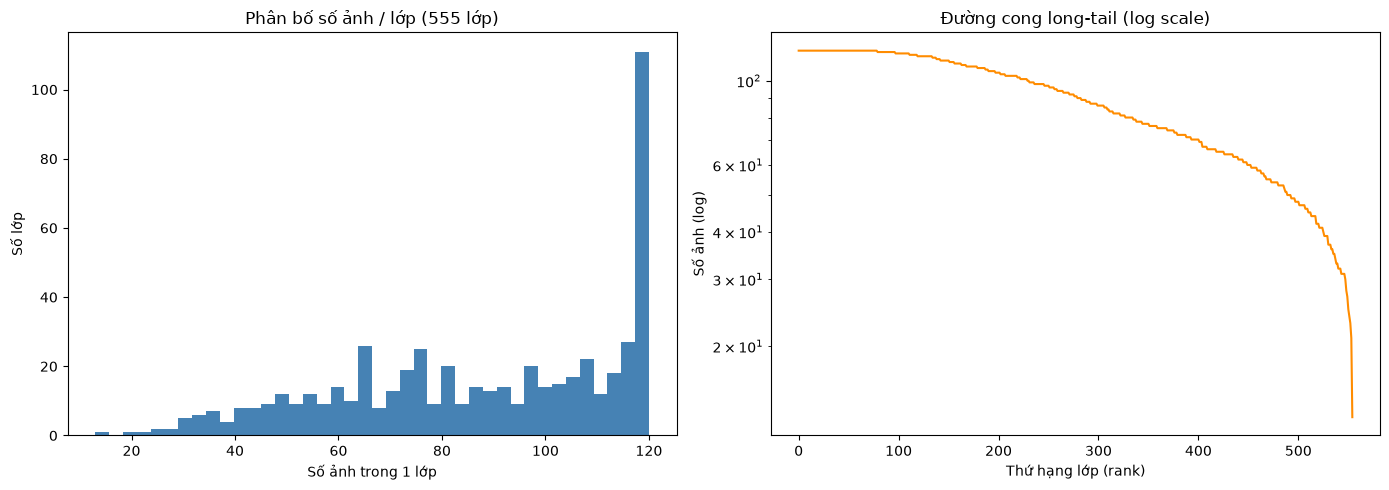

In [5]:
class_counts = df['class_id'].value_counts().rename('count').to_frame()
class_counts['class_name'] = class_counts.index.map(class_name_map)
class_counts = class_counts.reset_index().rename(columns={'index': 'class_id'})

desc = class_counts['count'].describe()
imbalance_ratio = class_counts['count'].max() / class_counts['count'].min()
print(desc)
print('\nImbalance ratio (max/min):', round(imbalance_ratio, 2))
print('Số lớp có ít hơn 20 ảnh:', (class_counts['count'] < 20).sum())
print('Số lớp có ít hơn 30 ảnh (ít hơn ngưỡng train/test hợp lý):', (class_counts['count'] < 30).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(class_counts['count'], bins=40, color='steelblue')
axes[0].set_title('Phân bố số ảnh / lớp (555 lớp)')
axes[0].set_xlabel('Số ảnh trong 1 lớp')
axes[0].set_ylabel('Số lớp')

sorted_counts = class_counts['count'].sort_values(ascending=False).values
axes[1].plot(sorted_counts, color='darkorange')
axes[1].set_yscale('log')
axes[1].set_title('Đường cong long-tail (log scale)')
axes[1].set_xlabel('Thứ hạng lớp (rank)')
axes[1].set_ylabel('Số ảnh (log)')
plt.tight_layout()
plt.show()


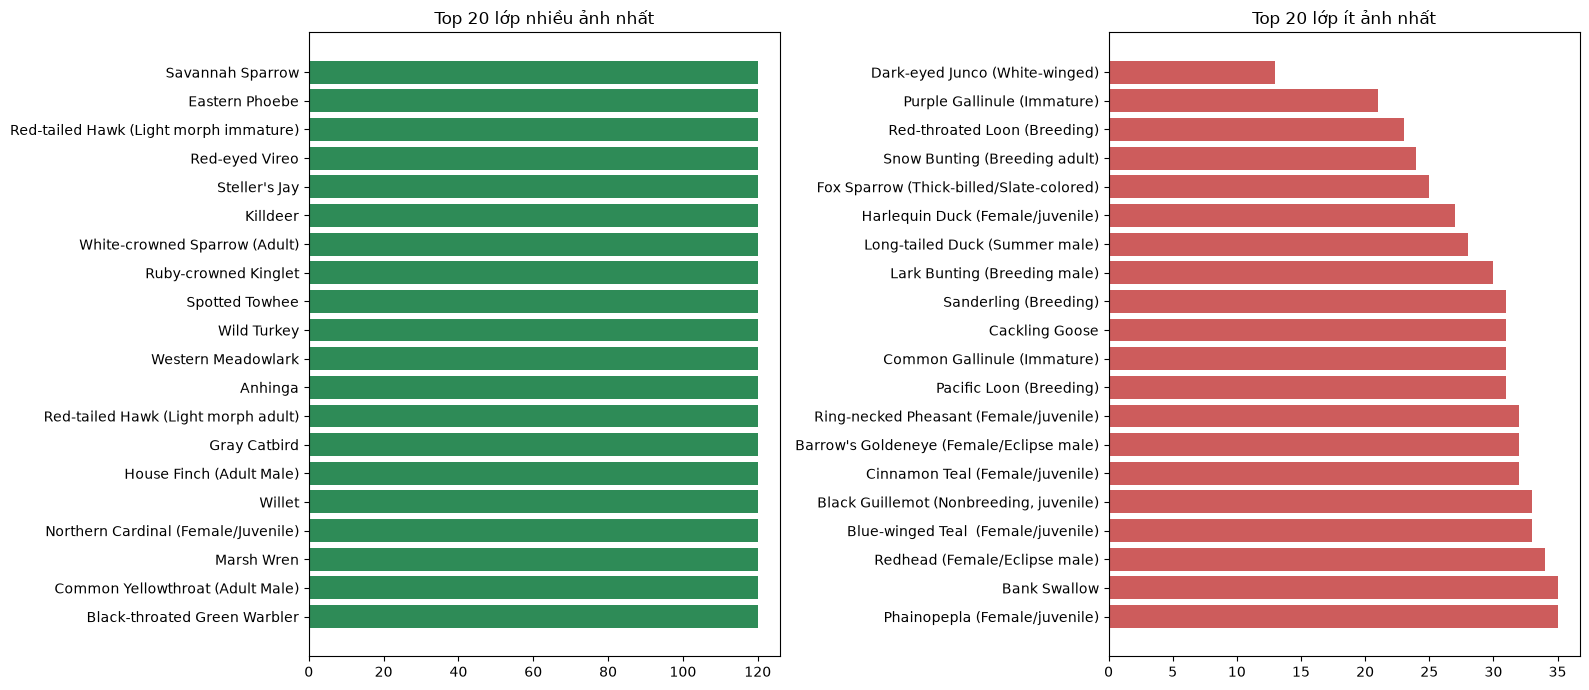

In [6]:
top20 = class_counts.sort_values('count', ascending=False).head(20)
bottom20 = class_counts.sort_values('count', ascending=True).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top20['class_name'][::-1], top20['count'][::-1], color='seagreen')
axes[0].set_title('Top 20 lớp nhiều ảnh nhất')
axes[1].barh(bottom20['class_name'][::-1], bottom20['count'][::-1], color='indianred')
axes[1].set_title('Top 20 lớp ít ảnh nhất')
plt.tight_layout()
plt.show()


## 5. Phân cấp phân loại (Taxonomy hierarchy)

Cây phân loại: `root (Birds, id=0) -> order -> family/genus -> species (leaf)`.
Phân tích này giúp: (a) hiểu dữ liệu phân bố ra sao theo bộ chim, (b) tìm nhóm phù hợp để
tạo bài toán **binary classification** (dự án #1) và **seen/unseen split** cho **zero-shot** (dự án #3).


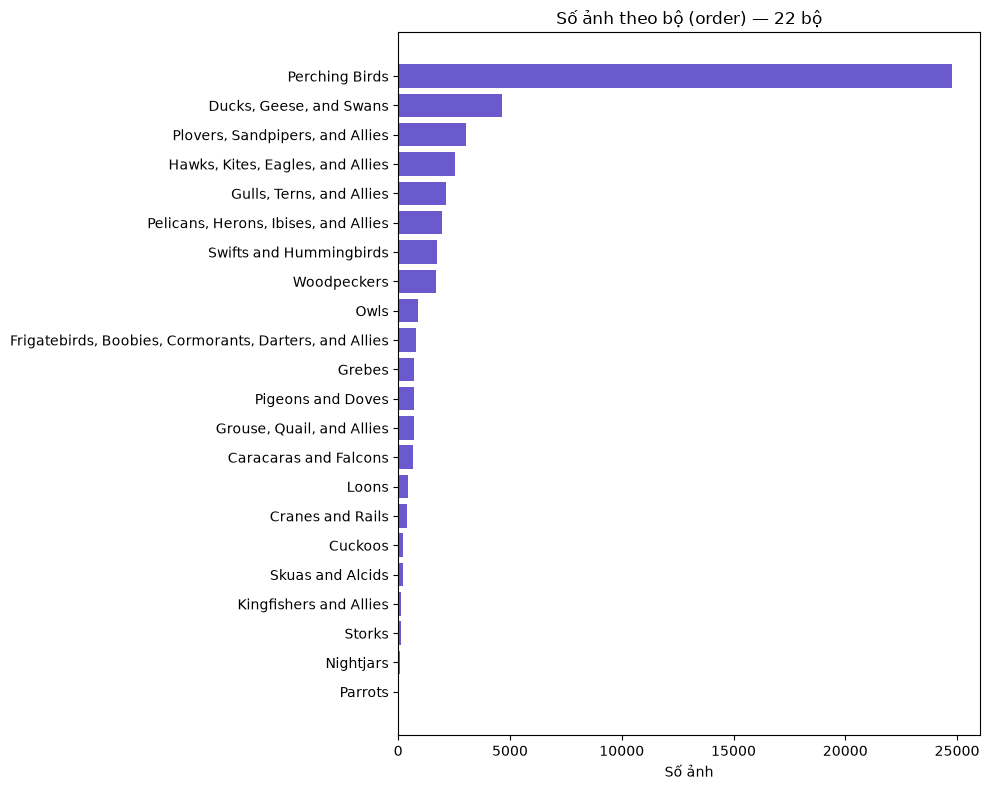

,n_images,n_species
order_name,,
Perching Birds,24787,265
"Ducks, Geese, and Swans",4662,70
"Plovers, Sandpipers, and Allies",3032,32
"Hawks, Kites, Eagles, and Allies",2528,29
"Gulls, Terns, and Allies",2129,26
"Pelicans, Herons, Ibises, and Allies",1961,21
Swifts and Hummingbirds,1748,21
Woodpeckers,1672,16
Owls,872,9


In [7]:
order_counts = df.groupby('order_name')['image_id'].count().sort_values(ascending=False)
n_species_per_order = df.groupby('order_name')['class_id'].nunique().reindex(order_counts.index)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(order_counts.index[::-1], order_counts.values[::-1], color='slateblue')
ax.set_title(f'Số ảnh theo bộ (order) — {n_orders} bộ')
ax.set_xlabel('Số ảnh')
plt.tight_layout()
plt.show()

pd.DataFrame({'n_images': order_counts, 'n_species': n_species_per_order}).sort_values('n_images', ascending=False)


In [8]:
depth_counts = df.drop_duplicates('class_id')['taxonomy_depth'].value_counts().sort_index()
print('Phân bố độ sâu (depth) của 555 lớp lá trong cây phân loại:')
print(depth_counts)

children_count = df_hierarchy['parent_id'].value_counts()
print('\nSố node con trung bình / node cha:', round(children_count.mean(), 2))
print('Node cha có nhiều con nhất:', class_name_map.get(children_count.idxmax()), '->', children_count.max(), 'con')


Phân bố độ sâu (depth) của 555 lớp lá trong cây phân loại:
taxonomy_depth
3    290
4    265
Name: count, dtype: int64

Số node con trung bình / node cha: 2.21
Node cha có nhiều con nhất: Ducks, Geese, and Swans -> 39 con


## 6. Kích thước ảnh & tỉ lệ khung hình

Dùng trực tiếp `sizes.txt` (không cần mở từng ảnh) để phân tích resolution — quyết định
kích thước resize đầu vào hợp lý cho CNN/ResNet.


              width       height  aspect_ratio    image_area
count  48562.000000  48562.00000  48562.000000  4.856200e+04
mean     898.508669    712.33555      1.298883  6.468588e+05
std      173.178038    152.49441      0.278957  1.866375e+05
min       90.000000     98.00000      0.449495  9.000000e+03
25%      800.000000    639.00000      1.244228  5.120000e+05
50%     1024.000000    683.00000      1.350923  6.993920e+05
75%     1024.000000    780.00000      1.499268  7.854080e+05
max     1024.000000   1024.00000      5.120000  1.048576e+06


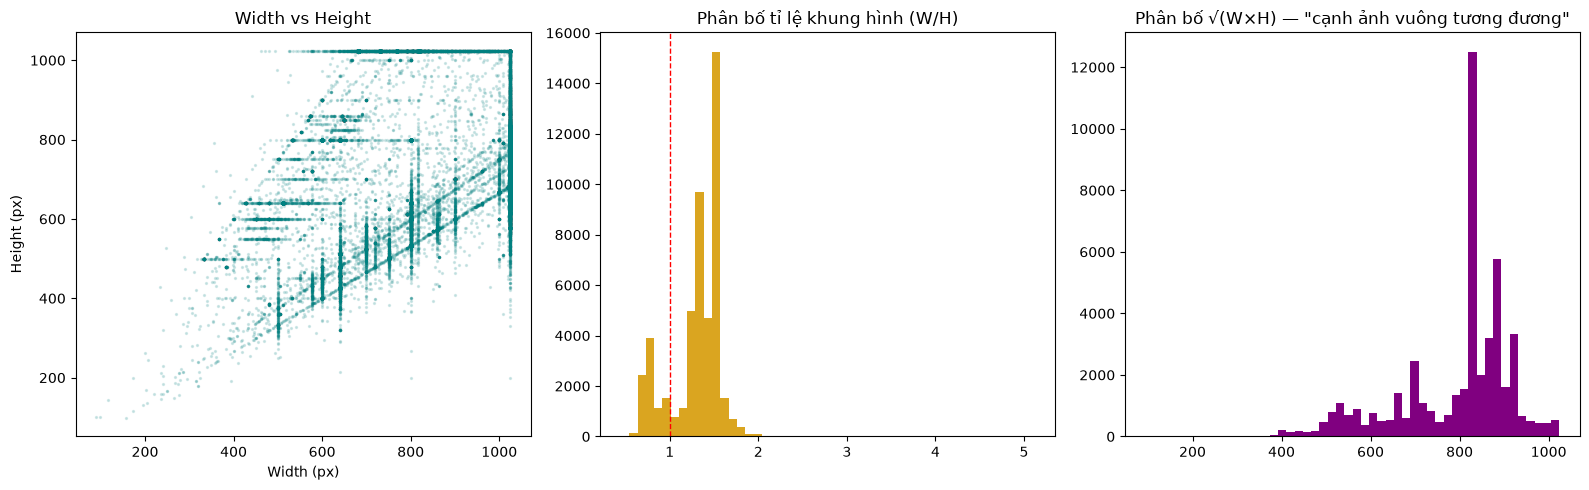


% ảnh có cạnh nhỏ nhất < 224px: 0.09 %


In [9]:
print(df[['width', 'height', 'aspect_ratio', 'image_area']].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(df['width'], df['height'], s=2, alpha=0.15, color='teal')
axes[0].set_title('Width vs Height')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')

axes[1].hist(df['aspect_ratio'], bins=50, color='goldenrod')
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Phân bố tỉ lệ khung hình (W/H)')

axes[2].hist(np.sqrt(df['image_area']), bins=50, color='purple')
axes[2].set_title('Phân bố √(W×H) — "cạnh ảnh vuông tương đương"')
plt.tight_layout()
plt.show()

print('\n% ảnh có cạnh nhỏ nhất < 224px:',
      round((df[['width', 'height']].min(axis=1) < 224).mean() * 100, 2), '%')


## 7. Bounding box

Mỗi ảnh có **1 bounding box** duy nhất bao quanh con chim. Tỉ lệ diện tích bbox/ảnh cho biết
con chim chiếm bao nhiêu phần khung hình — ảnh hưởng tới việc có nên crop theo bbox trước khi
đưa vào CNN hay không.


             bbox_w        bbox_h  bbox_area_ratio
count  48562.000000  48562.000000     48562.000000
mean     453.897286    406.371010         0.306607
std      187.767897    168.061559         0.175004
min       30.000000     35.000000         0.003558
25%      309.000000    282.000000         0.172700
50%      434.000000    387.000000         0.282562
75%      581.000000    509.000000         0.414809
max     1024.000000   1024.000000         1.000000

Số ảnh có bbox vượt ra ngoài biên ảnh: 201 / 48562 (0.41%)


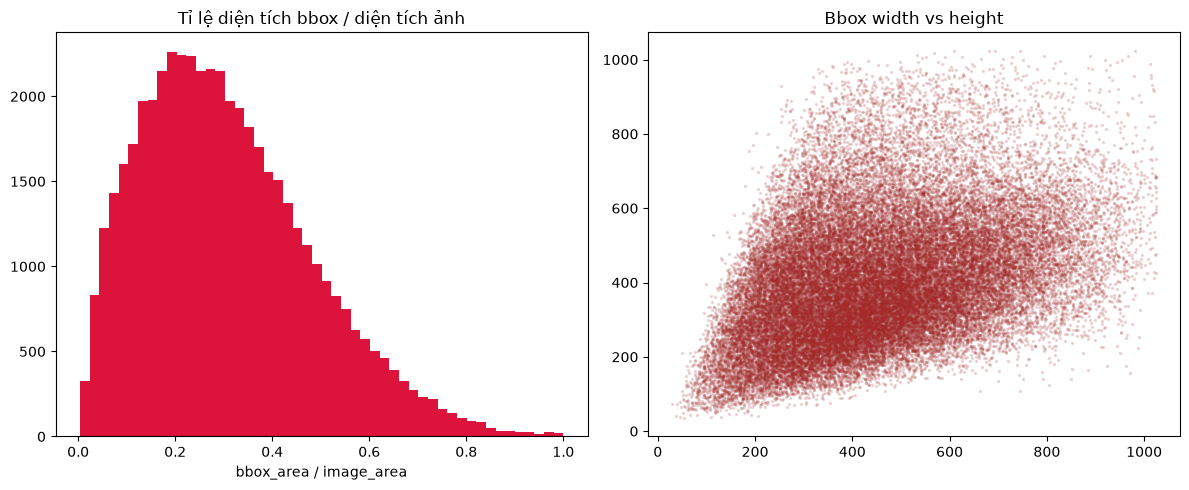

In [10]:
print(df[['bbox_w', 'bbox_h', 'bbox_area_ratio']].describe())

# Kiểm tra bbox có vượt ra ngoài biên ảnh không (lỗi annotation)
bad_bbox = df[(df['bbox_x'] + df['bbox_w'] > df['width']) | (df['bbox_y'] + df['bbox_h'] > df['height'])]
print(f"\nSố ảnh có bbox vượt ra ngoài biên ảnh: {len(bad_bbox)} / {len(df)} ({len(bad_bbox)/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['bbox_area_ratio'], bins=50, color='crimson')
axes[0].set_title('Tỉ lệ diện tích bbox / diện tích ảnh')
axes[0].set_xlabel('bbox_area / image_area')

axes[1].scatter(df['bbox_w'], df['bbox_h'], s=2, alpha=0.15, color='brown')
axes[1].set_title('Bbox width vs height')
plt.tight_layout()
plt.show()


## 8. Bộ phận cơ thể (parts / keypoints)

11 bộ phận: bill, crown, nape, left eye, right eye, belly, breast, back, tail, left wing, right wing.
Không bắt buộc cho 3 dự án hiện tại, nhưng cho biết mức độ "đầy đủ" của annotation — hữu ích nếu
sau này mở rộng sang part-based / pose-aware classification.


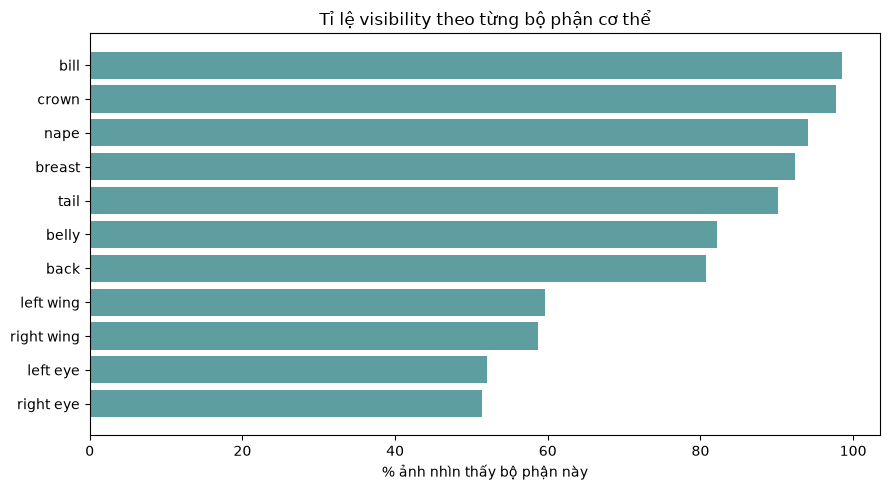

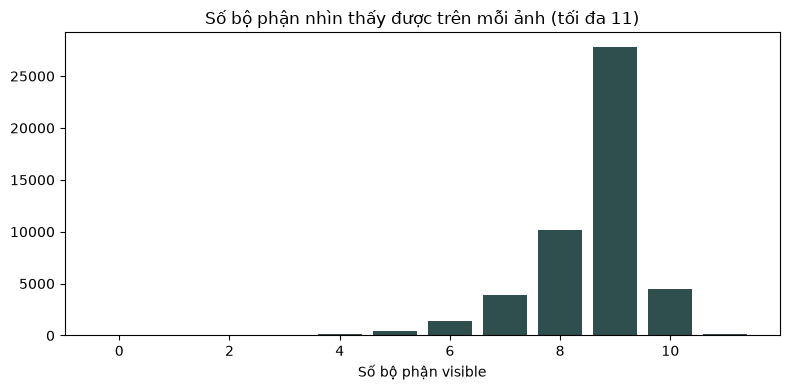

In [11]:
part_visibility = df_parts.merge(df_part_names, on='part_id').groupby('part_name')['visible'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(part_visibility.index[::-1], part_visibility.values[::-1], color='cadetblue')
ax.set_xlabel('% ảnh nhìn thấy bộ phận này')
ax.set_title('Tỉ lệ visibility theo từng bộ phận cơ thể')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['n_visible_parts'].dropna(), bins=range(0, 13), color='darkslategray', align='left', rwidth=0.8)
ax.set_title('Số bộ phận nhìn thấy được trên mỗi ảnh (tối đa 11)')
ax.set_xlabel('Số bộ phận visible')
plt.tight_layout()
plt.show()


## 9. Nhiếp ảnh gia & rủi ro rò rỉ dữ liệu (leakage)

`photographers.txt` chỉ là metadata mô tả, **không phải feature huấn luyện**. Tuy nhiên nếu cùng
1 nhiếp ảnh gia có ảnh ở cả train và test, mô hình có thể học "phong cách chụp" thay vì đặc điểm
loài chim, gây đánh giá lạc quan giả (optimistic bias). Ta kiểm tra mức độ overlap này.


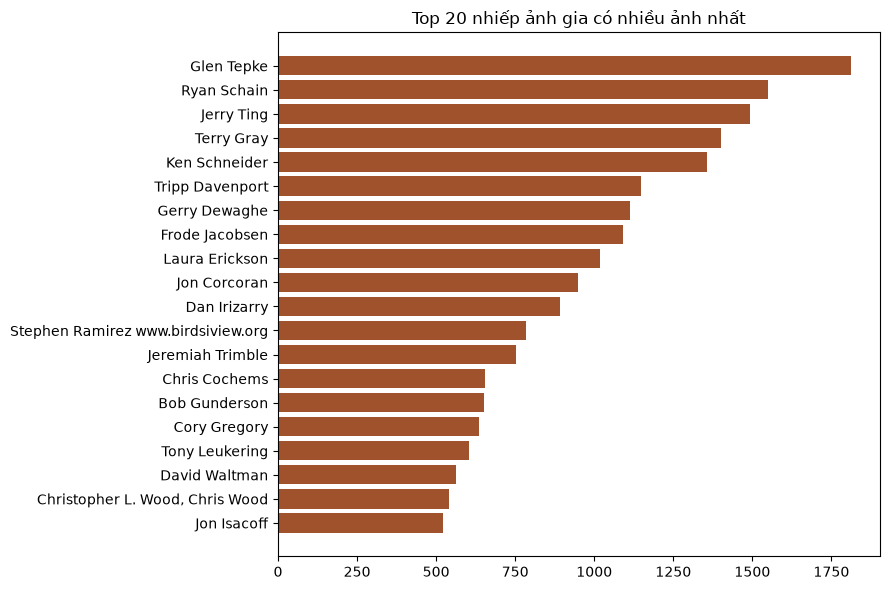

Số nhiếp ảnh gia có ảnh ở CẢ train & test: 610 / 1031
Số ảnh liên quan tới các nhiếp ảnh gia này: 47848 / 48562 (98.5%)


In [12]:
top_photo = df['photographer'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_photo.index[::-1], top_photo.values[::-1], color='sienna')
ax.set_title('Top 20 nhiếp ảnh gia có nhiều ảnh nhất')
plt.tight_layout()
plt.show()

photo_split = df.groupby('photographer')['split'].apply(lambda s: set(s))
both_splits = photo_split[photo_split.apply(lambda s: len(s) > 1)]
n_images_overlap = df[df['photographer'].isin(both_splits.index)].shape[0]
print(f"Số nhiếp ảnh gia có ảnh ở CẢ train & test: {len(both_splits)} / {df['photographer'].nunique()}")
print(f"Số ảnh liên quan tới các nhiếp ảnh gia này: {n_images_overlap} / {len(df)} ({n_images_overlap/len(df)*100:.1f}%)")


## 10. Train/test split theo từng lớp

Kiểm tra xem split gợi ý (`train_test_split.txt`) có đảm bảo **mỗi lớp đều có mẫu ở cả train và test**
hay không — quan trọng để đánh giá công bằng cho bài toán 555-class.


Số lớp KHÔNG có ảnh test: 0
Số lớp KHÔNG có ảnh train: 0
Số ảnh train ít nhất trong 1 lớp: 4
Số ảnh test ít nhất trong 1 lớp: 9


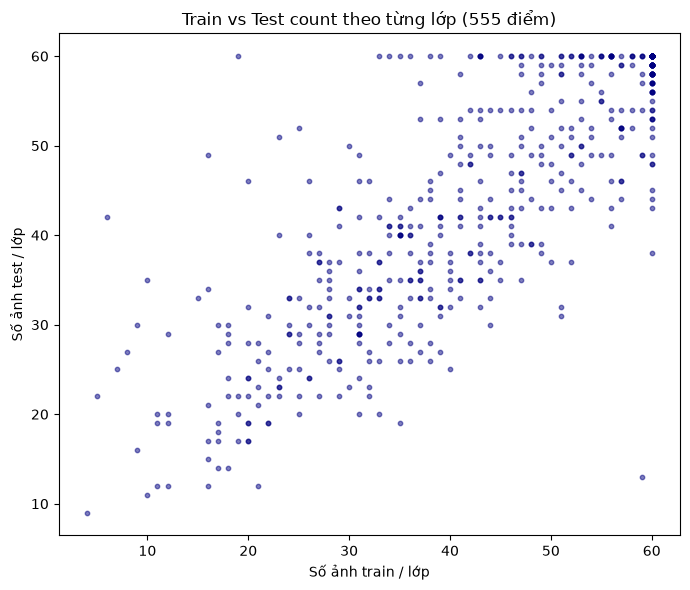

split,test,train,class_name
class_id,,,
975,9,4,Dark-eyed Junco (White-winged)
627,22,5,Harlequin Duck (Female/juvenile)
815,42,6,Boreal Chickadee
633,25,7,Barrow's Goldeneye (Female/Eclipse male)
807,27,8,Bank Swallow
625,30,9,Greater Scaup (Female/Eclipse male)
1006,16,9,Fox Sparrow (Thick-billed/Slate-colored)
664,11,10,Purple Gallinule (Immature)
334,35,10,Barrow's Goldeneye (Breeding male)


In [13]:
split_per_class = df.groupby(['class_id', 'split']).size().unstack(fill_value=0)
split_per_class['class_name'] = split_per_class.index.map(class_name_map)

n_no_test = (split_per_class.get('test', 0) == 0).sum()
n_no_train = (split_per_class.get('train', 0) == 0).sum()
print(f"Số lớp KHÔNG có ảnh test: {n_no_test}")
print(f"Số lớp KHÔNG có ảnh train: {n_no_train}")
print(f"Số ảnh train ít nhất trong 1 lớp: {split_per_class['train'].min()}")
print(f"Số ảnh test ít nhất trong 1 lớp: {split_per_class['test'].min()}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(split_per_class['train'], split_per_class['test'], s=10, alpha=0.5, color='navy')
ax.set_xlabel('Số ảnh train / lớp')
ax.set_ylabel('Số ảnh test / lớp')
ax.set_title('Train vs Test count theo từng lớp (555 điểm)')
plt.tight_layout()
plt.show()

split_per_class.sort_values('train').head(10)


## 11. Kiểm tra tính toàn vẹn dữ liệu (data integrity)

- File ảnh trên đĩa có khớp với `images.txt` không (thiếu/thừa file).
- Có `image_id`/`class_id` nào bị lệch tham chiếu giữa các file không.
- Ảnh có mở được bằng PIL không (kiểm tra nhanh trên mẫu ngẫu nhiên để không mất quá nhiều thời gian).


In [14]:
# 1) Kiểm tra tồn tại file trên đĩa (nhanh, chỉ stat file, không đọc nội dung)
exists_mask = df['full_path'].apply(os.path.exists)
print(f"Số ảnh liệt kê trong images.txt nhưng KHÔNG tồn tại trên đĩa: {(~exists_mask).sum()} / {len(df)}")

# 2) Đối chiếu số file thực tế trên đĩa so với images.txt
actual_files = list(IMAGES_DIR.rglob('*.jpg'))
print(f"Số file .jpg thực tế trong images/: {len(actual_files)}  (images.txt liệt kê: {len(df_images)})")

# 3) class_id trong image_class_labels.txt có mặt trong classes.txt không
missing_class_ref = set(df_labels['class_id']) - set(df_classes['class_id'])
print(f"class_id trong labels nhưng thiếu trong classes.txt: {missing_class_ref}")

# 4) Giá trị NaN sau khi merge (image_id không khớp giữa các file)
print('\nSố dòng bị thiếu dữ liệu (NaN) sau merge, theo cột:')
print(df[['class_id', 'width', 'height', 'bbox_w', 'is_train', 'photographer']].isna().sum())

# 5) Kiểm tra ảnh mở được bằng PIL trên 1 mẫu ngẫu nhiên (đủ để phát hiện file hỏng phổ biến)
sample_paths = df['full_path'].sample(n=min(300, len(df)), random_state=42)
corrupt = []
for p in sample_paths:
    try:
        with Image.open(p) as im:
            im.verify()
    except Exception as e:
        corrupt.append((p, str(e)))
print(f"\nKiểm tra ngẫu nhiên {len(sample_paths)} ảnh bằng PIL.verify() -> {len(corrupt)} ảnh lỗi")
for p, e in corrupt[:10]:
    print(' -', p, '->', e)


Số ảnh liệt kê trong images.txt nhưng KHÔNG tồn tại trên đĩa: 0 / 48562
Số file .jpg thực tế trong images/: 48562  (images.txt liệt kê: 48562)


class_id trong labels nhưng thiếu trong classes.txt: set()

Số dòng bị thiếu dữ liệu (NaN) sau merge, theo cột:
class_id        0
width           0
height          0
bbox_w          0
is_train        0
photographer    0
dtype: int64

Kiểm tra ngẫu nhiên 300 ảnh bằng PIL.verify() -> 0 ảnh lỗi


## 12. Trực quan hóa ảnh mẫu

Hiển thị ngẫu nhiên một số ảnh cùng bounding box, tên lớp và tập (train/test) để kiểm tra
trực quan chất lượng annotation.


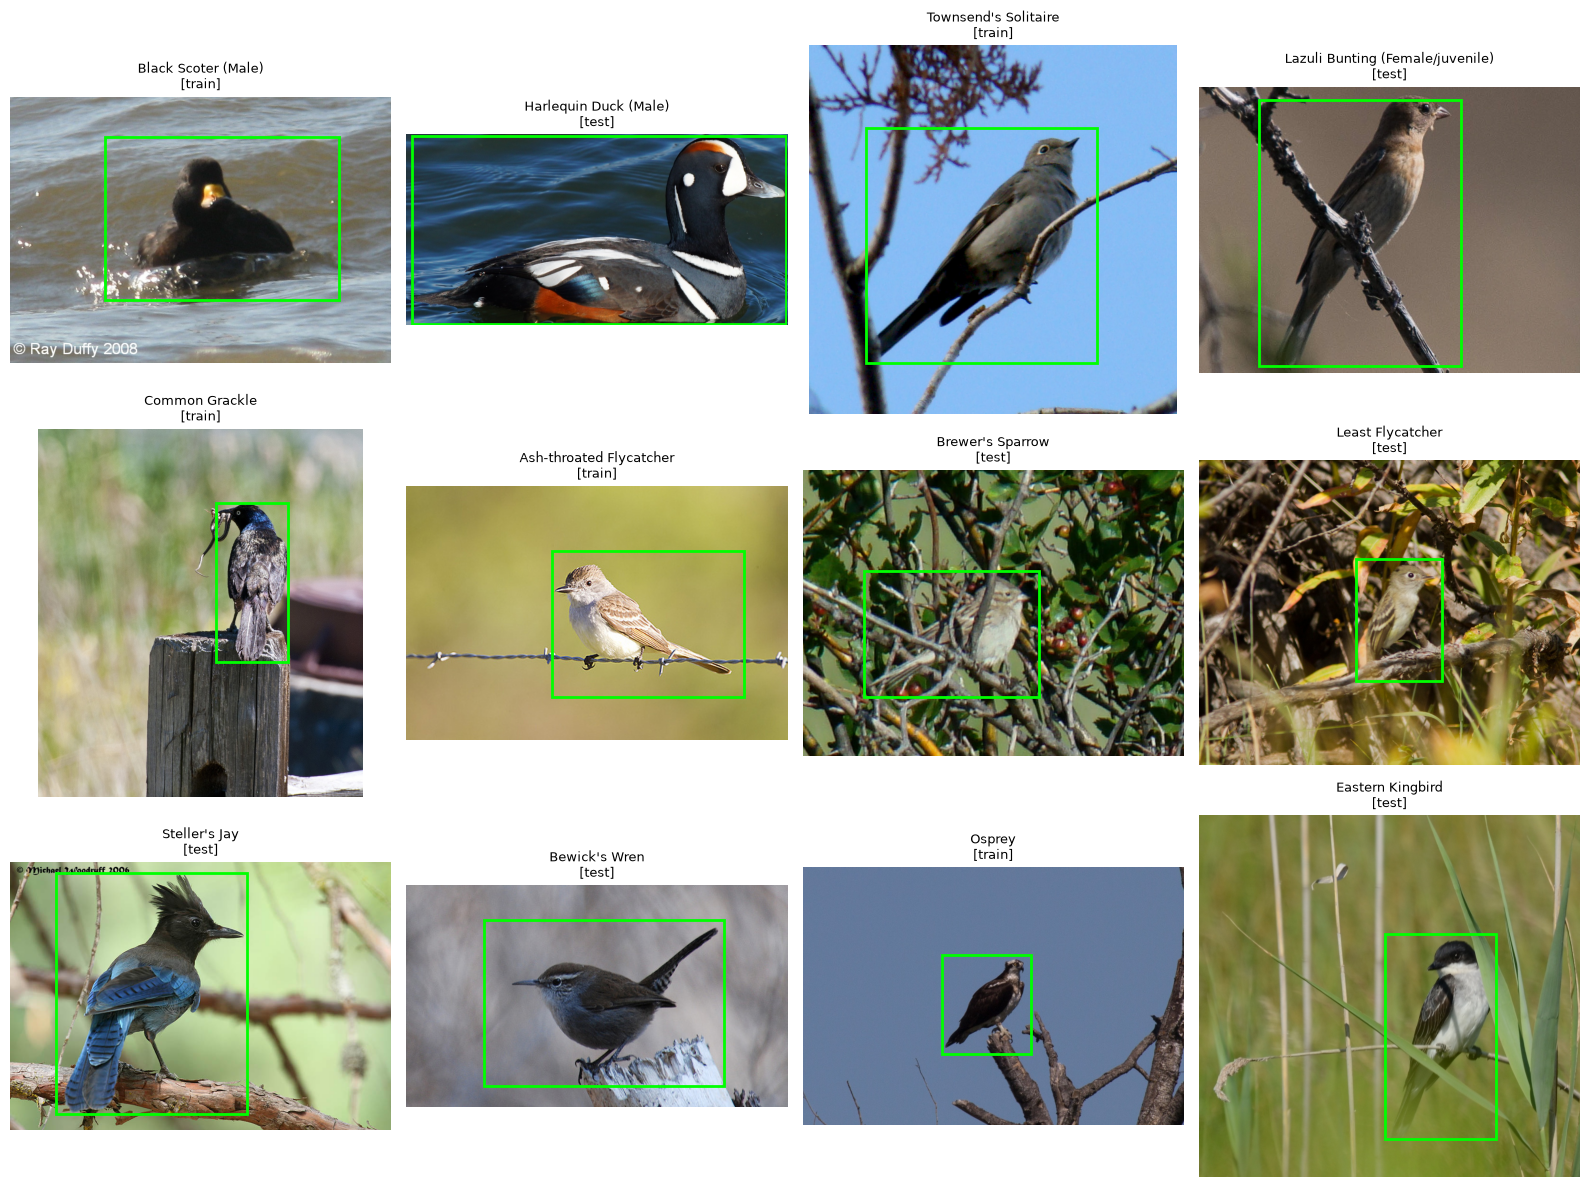

In [15]:
def show_sample_grid(df, n=12, seed=0):
    sample = df.sample(n=n, random_state=seed)
    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sample.iterrows()):
        try:
            with Image.open(row['full_path']) as im:
                ax.imshow(im)
        except Exception:
            ax.text(0.5, 0.5, 'Không mở được ảnh', ha='center')
        rect = plt.Rectangle((row['bbox_x'], row['bbox_y']), row['bbox_w'], row['bbox_h'],
                              fill=False, edgecolor='lime', linewidth=2)
        ax.add_patch(rect)
        ax.set_title(f"{row['class_name']}\n[{row['split']}]", fontsize=9)
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_grid(df, n=12, seed=42)


## 13. Đánh giá khả thi cho 3 dự án

### 13.1 Dự án #1 — Phân loại nhị phân (Binary) bằng CNN / ResNet

NABirds vốn là bài toán **555-class**, không có sẵn nhãn nhị phân. Cần **tự định nghĩa** bài toán
binary từ metadata sẵn có. Vài phương án khả thi, dùng ngay `order_name` / `class_name` đã tính ở trên:

- **Theo bộ (order) lớn nhất vs phần còn lại**: ví dụ "Perching Birds (Passeriformes)" vs "tất cả các bộ khác".
- **Cặp loài dễ nhầm lẫn** (fine-grained, khó hơn): ví dụ 2 lớp cùng chi trong `classes.txt`
  (VD "Baltimore Oriole" vs "Bullock's Oriole").
- **Trống/mái hoặc non/trưởng thành** cho cùng 1 loài (tận dụng các lớp dạng
  "(Female/Immature male)", "(Juvenile)" có sẵn trong `classes.txt`).

Cell dưới đây kiểm tra độ cân bằng (balance) của phương án đầu tiên — nhóm theo `order_name` —
để chọn ra phương án binary khả thi nhất về mặt số lượng mẫu.


Phương án binary: 'Perching Birds' vs 'Others'
is_largest_order
Perching Birds    24787
Others            23775
Name: count, dtype: int64
Tỉ lệ lớp positive: 51.04 %


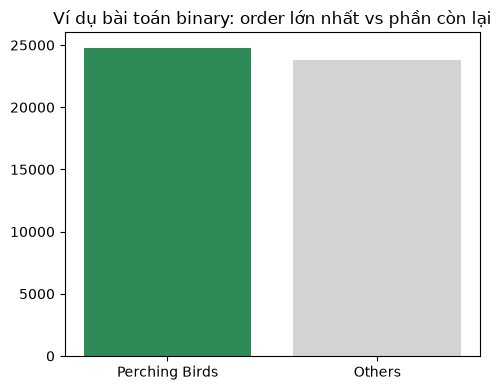

In [16]:
largest_order = order_counts.idxmax()
df['is_largest_order'] = (df['order_name'] == largest_order).astype(int)
binary_counts = df['is_largest_order'].value_counts().rename({1: largest_order, 0: 'Others'})
print(f"Phương án binary: '{largest_order}' vs 'Others'")
print(binary_counts)
print('Tỉ lệ lớp positive:', round(binary_counts.get(largest_order, 0) / len(df) * 100, 2), '%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(binary_counts.index.astype(str), binary_counts.values, color=['seagreen', 'lightgray'])
ax.set_title('Ví dụ bài toán binary: order lớn nhất vs phần còn lại')
plt.tight_layout()
plt.show()


### 13.2 Dự án #2 — Phân loại đa lớp (multi-class, softmax, 555 lớp)

Đây chính là bài toán gốc của NABirds. Điểm mấu chốt rút ra từ EDA ở Mục 4:

- **555 lớp, mất cân bằng đáng kể** (xem `imbalance_ratio` ở Mục 4) → cần class weighting,
  oversampling nhóm ít mẫu, hoặc focal loss khi train softmax 555-way.
- Train/test split gợi ý (Mục 10) đã chia theo tỉ lệ khá cân bằng (~50/50 tổng thể) nhưng cần
  kiểm tra riêng từng lớp có bị 0 mẫu ở 1 phía không (đã kiểm tra ở Mục 10).
- Có thể bắt đầu thử nghiệm nhanh trên **top-N lớp nhiều ảnh nhất** (ví dụ top 20, Mục 4) trước khi
  scale lên đủ 555 lớp, để giảm thời gian debug pipeline.


### 13.3 Dự án #3 — Zero-shot classification

Yêu cầu dữ liệu **text/attribute mô tả lớp** để model học liên kết ảnh–ngữ nghĩa cho lớp chưa
từng thấy khi train. Với NABirds hiện tại:

- **Có sẵn**: tên loài dạng text tự nhiên (`classes.txt`) + cây phân loại phân cấp (`hierarchy.txt`)
  — đủ để dùng làm text prompt cho zero-shot kiểu CLIP (ví dụ prompt `"a photo of a {class_name}"`).
- **Không có sẵn**: attribute vector chi tiết (màu sắc, hình dạng mỏ, kích thước...) như bộ CUB-200-2011
  (`attributes.txt`) — nghĩa là **không thể** làm attribute-based ZSL kiểu Lampert/DAP, chỉ có thể làm
  **text-embedding-based ZSL** (CLIP, hoặc tự sinh caption/attribute bằng LLM khác nếu cần).
- Cần tự tạo **seen/unseen class split**: ví dụ giữ lại 1–2 bộ (order) hiếm gặp làm "unseen" hoàn toàn
  (không xuất hiện lúc train), phần còn lại làm "seen" — tận dụng `order_name` đã tính ở Mục 5.

Cell dưới đây minh hoạ cách tạo 1 seen/unseen split theo order (chỉ để tham khảo, chưa chốt final).


In [17]:
orders_sorted_by_size = order_counts.sort_values().index.tolist()
n_unseen_orders = max(1, int(len(orders_sorted_by_size) * 0.15))
unseen_orders = orders_sorted_by_size[:n_unseen_orders]  # chọn các order ít ảnh nhất làm unseen (ví dụ)
seen_orders = [o for o in orders_sorted_by_size if o not in unseen_orders]

unseen_classes = sorted(df.loc[df['order_name'].isin(unseen_orders), 'class_id'].unique())
seen_classes = sorted(df.loc[df['order_name'].isin(seen_orders), 'class_id'].unique())

print(f"Số order chọn làm UNSEEN (ví dụ): {len(unseen_orders)} -> {unseen_orders}")
print(f"Số lớp (species) thuộc nhóm unseen: {len(unseen_classes)} / {df['class_id'].nunique()}")
print(f"Số lớp (species) thuộc nhóm seen  : {len(seen_classes)} / {df['class_id'].nunique()}")
print(f"Số ảnh thuộc nhóm unseen: {df['order_name'].isin(unseen_orders).sum()} / {len(df)}")


Số order chọn làm UNSEEN (ví dụ): 3 -> ['Parrots', 'Nightjars', 'Storks']
Số lớp (species) thuộc nhóm unseen: 3 / 555
Số lớp (species) thuộc nhóm seen  : 552 / 555
Số ảnh thuộc nhóm unseen: 236 / 48562


## 14. Tổng kết & khuyến nghị

**Về dataset:**
- 48,562 ảnh, 555 lớp lá (loài/biến thể), phân cấp trong cây phân loại 1,010 node (22 bộ ở cấp cao nhất).
- Split train/test gợi ý sẵn (~50.7% train / 49.3% test), tỉ lệ khá cân bằng tổng thể.
- Ảnh có độ phân giải khá cao (đa số > 224px cạnh nhỏ nhất) → resize/crop tuỳ ý cho CNN/ResNet.
- Có bounding box và 11 keypoint bộ phận cho **mọi ảnh** — annotation đầy đủ, ít NaN.
- Rủi ro cần lưu ý: mất cân bằng lớp mạnh (long-tail) và khả năng overlap nhiếp ảnh gia giữa
  train/test (xem số liệu cụ thể ở Mục 9).

**Khuyến nghị cho từng dự án:**
1. **Binary (CNN/ResNet)**: tự định nghĩa bài toán nhị phân từ `order_name` hoặc cặp loài dễ nhầm —
   dùng bảng ở Mục 13.1 làm điểm khởi đầu.
2. **Multi-class softmax (555 lớp)**: xử lý imbalance (class weight/oversampling), thử nghiệm trước
   trên top-N lớp lớn nhất, dùng đúng split trong `train_test_split.txt` nhưng loại/gộp các lớp
   có quá ít mẫu nếu cần.
3. **Zero-shot**: dùng tên lớp text + cây phân loại làm cơ sở cho text-embedding-based ZSL (CLIP-style);
   tự tạo seen/unseen split theo order (ví dụ ở Mục 13.3); không có attribute vector nên loại các
   phương pháp attribute-based ZSL truyền thống.

**Bước tiếp theo:** dùng môi trường conda `deeplearning` (CUDA) để xây dựng pipeline huấn luyện
riêng cho từng dự án ở các notebook/script kế tiếp.
